# Preparing Intraday EUR/USD Data for a Simple Contrarian Strategy

This notebook is for educational purposes only. It is not financial advice. The data and strategy examples are simplified and do not account for all real-world trading frictions such as spreads, commissions, slippage, execution delays, liquidity constraints, or risk management.


## Introduction

In the previous notebook, we introduced the idea of simple momentum and contrarian strategies.

A simple contrarian strategy assumes that recent price movement may reverse. For example:

- if the most recent return was negative, a contrarian strategy may go long
- if the most recent return was positive, a contrarian strategy may go short

Before we can test that idea, we need to prepare intraday price data.

In this notebook, we will:

- import intraday EUR/USD price data
- inspect the dataset
- check the time range and data frequency
- plot the price series
- zoom into one month
- calculate log returns
- drop the first missing return row

The actual strategy logic will be added in the next notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)


We use:

- `pandas` for data handling
- `numpy` for numerical calculations
- `matplotlib` for visualisation
- `Path` to check whether the CSV file exists


## Load or Create Intraday Data

The lecture uses an `intraday.csv` file containing EUR/USD intraday close prices. The data has a 6-hour frequency.

If the file exists, we will load it. If it does not exist, we will create synthetic 6-hour EUR/USD-style data from 2018 to 2019 so the notebook remains runnable.


In [3]:
data_path = Path("intraday.csv")

if data_path.exists():
    print("Loading intraday.csv...")
    data = pd.read_csv(data_path, parse_dates=["time"], index_col="time")
else:
    print("intraday.csv not found. Creating synthetic 6-hour EUR/USD-style data...")

    np.random.seed(42)

    # 6-hour candles from the beginning of 2018 to the end of 2019
    dates = pd.date_range(
        start="2018-01-01 22:00:00",
        end="2019-12-31 22:00:00",
        freq="6h"
    )

    # Synthetic EUR/USD-style price path with slight downward drift
    log_returns = np.random.normal(loc=-0.00003, scale=0.0025, size=len(dates))
    prices = 1.20 * np.exp(log_returns.cumsum())

    data = pd.DataFrame({"EURUSD": prices}, index=dates)
    data.index.name = "time"

    data.to_csv(data_path)

data.head()


Loading intraday.csv...


,EURUSD
time,
2018-01-01 22:00:00,1.201455
2018-01-02 04:00:00,1.201004
2018-01-02 10:00:00,1.202914
2018-01-02 16:00:00,1.207467
2018-01-02 22:00:00,1.206724


The dataset should contain a timestamp index and one price column for EUR/USD. The price represents the close of each 6-hour candle.


## Standardise the Column Name

Depending on the CSV file, the price column may have a different name, such as `EURUSD`, `price`, `Close`, or `close`. To keep the rest of the notebook simple, rename the first column to `price`.


In [4]:
data = data.copy()

# Rename the first column to "price" for consistency
data.rename(columns={data.columns[0]: "price"}, inplace=True)

data.head()


,price
time,
2018-01-01 22:00:00,1.201455
2018-01-02 04:00:00,1.201004
2018-01-02 10:00:00,1.202914
2018-01-02 16:00:00,1.207467
2018-01-02 22:00:00,1.206724


From now on, the close price column will be called `price`.


## Inspect the Dataset

Before doing any analysis, inspect the structure of the data.


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2917 entries, 2018-01-01 22:00:00 to 2019-12-31 22:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2917 non-null   float64
dtypes: float64(1)
memory usage: 45.6 KB


In [6]:
data.describe()


,price
count,2917.000000
mean,1.300911
std,0.095234
min,1.125319
25%,1.196906
50%,1.337728
75%,1.383270
max,1.455575


In [7]:
data.index.min(), data.index.max()


(Timestamp('2018-01-01 22:00:00'), Timestamp('2019-12-31 22:00:00'))

This helps us confirm:

- the number of candles
- whether the index is datetime-based
- the start and end dates
- whether the price column contains missing values
- the general price range


## Check Missing Values

The lecture dataset has no missing values. If missing values exist in another dataset, we would need to decide how to handle them before backtesting.


In [8]:
data.isna().sum()


price    0
dtype: int64

In [9]:
data.dropna(subset=["price"], inplace=True)


## Check the Approximate Data Frequency

The lecture data uses 6-hour candles. We can check the time difference between consecutive timestamps.


In [10]:
data.index.to_series().diff().value_counts().head(10)


time
0 days 06:00:00    2916
Name: count, dtype: int64

For clean 6-hour data, the most common time difference should be around 6 hours. Some datasets may have gaps around weekends, holidays, or market closures.


## Plot the Full Price Series

Now plot the EUR/USD price series over the full period.


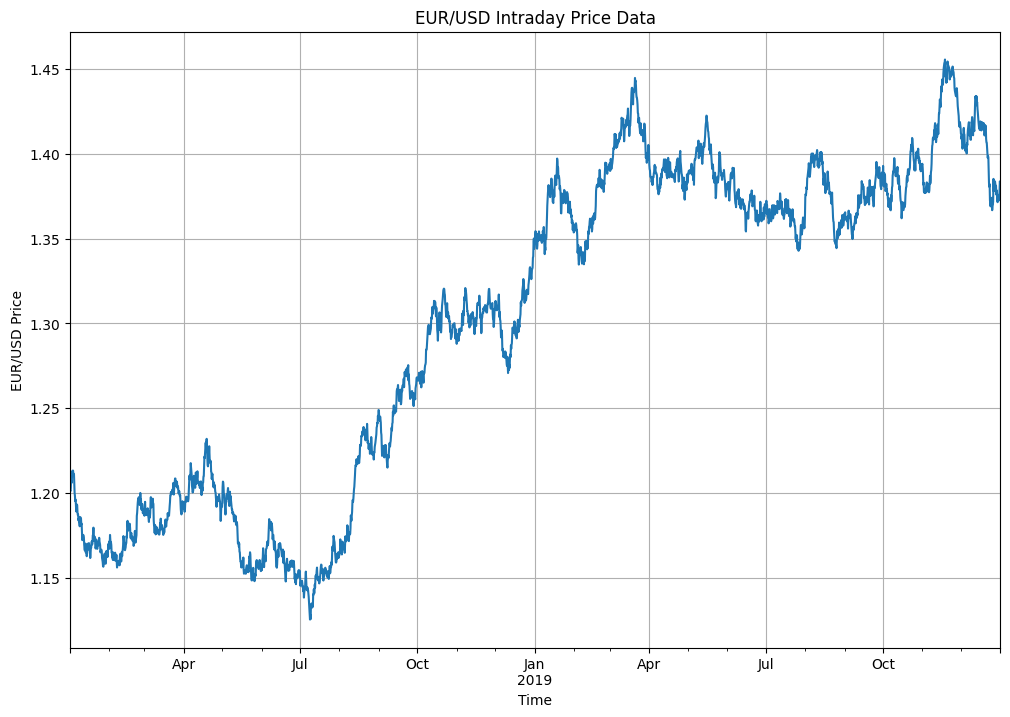

In [11]:
data["price"].plot(figsize=(12, 8))
plt.title("EUR/USD Intraday Price Data")
plt.xlabel("Time")
plt.ylabel("EUR/USD Price")
plt.grid(True)
plt.show()


In the lecture example, EUR/USD generally depreciated from the beginning of 2018 to the end of 2019. If synthetic data is used, the exact path will differ, but the workflow is the same.


## Zoom into One Month

It is useful to zoom into a shorter period to see the intraday candle structure more clearly. Here we select June 2019.


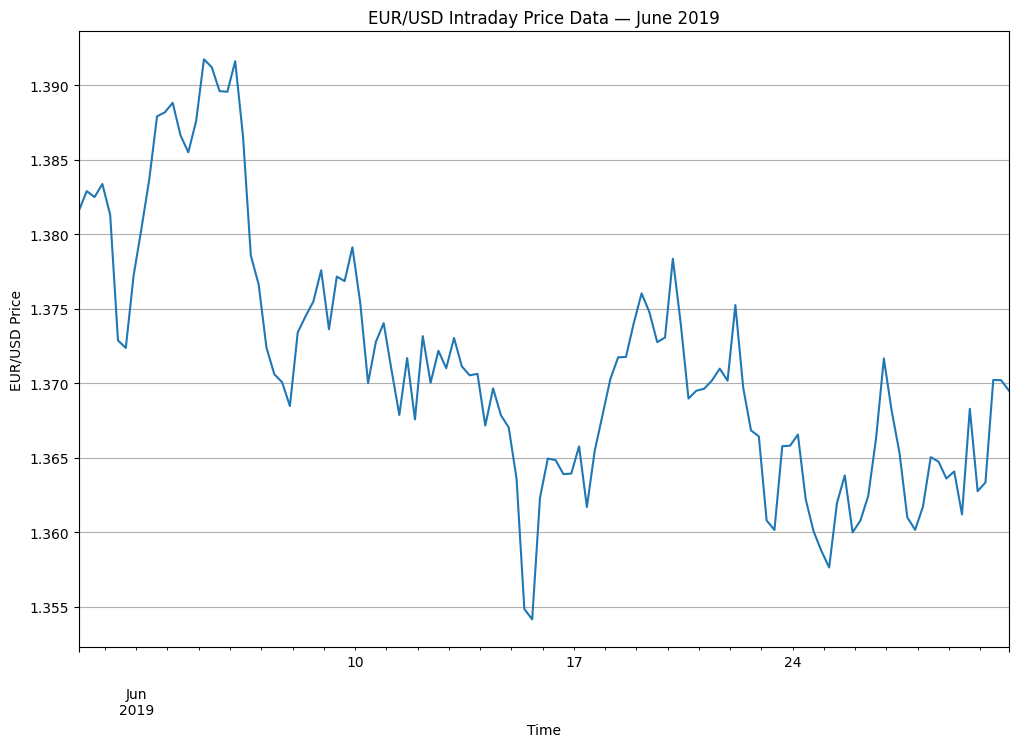

In [12]:
month_data = data.loc["2019-06"]

month_data["price"].plot(figsize=(12, 8))
plt.title("EUR/USD Intraday Price Data — June 2019")
plt.xlabel("Time")
plt.ylabel("EUR/USD Price")
plt.grid(True)
plt.show()


When plotting intraday data, straight horizontal or connecting lines around weekends can appear because FX markets are not continuously trading through the weekend in the same way as during weekdays. This is normal when plotting timestamped price observations as a continuous line.


## Calculate Log Returns

Most strategy backtests use returns rather than raw prices. Here we calculate log returns:

```python
log_return = log(current_price / previous_price)
```

Log returns are convenient because they can be added over time.


In [13]:
data["returns"] = np.log(data["price"] / data["price"].shift(1))

data.head()


,price,returns
time,,
2018-01-01 22:00:00,1.201455,NaN
2018-01-02 04:00:00,1.201004,-0.000376
2018-01-02 10:00:00,1.202914,0.001589
2018-01-02 16:00:00,1.207467,0.003778
2018-01-02 22:00:00,1.206724,-0.000615


The first return is missing because there is no previous price for the first candle.


## Drop the First Missing Return Row


In [14]:
data.dropna(inplace=True)

data.head()


,price,returns
time,,
2018-01-02 04:00:00,1.201004,-0.000376
2018-01-02 10:00:00,1.202914,0.001589
2018-01-02 16:00:00,1.207467,0.003778
2018-01-02 22:00:00,1.206724,-0.000615
2018-01-03 04:00:00,1.205981,-0.000615


After dropping the first row, the dataset is ready for the next step. It now contains:

- `price`
- `returns`


## Inspect the Prepared Data


In [15]:
data.tail()


,price,returns
time,,
2019-12-30 22:00:00,1.372472,-0.001857
2019-12-31 04:00:00,1.375034,0.001865
2019-12-31 10:00:00,1.377351,0.001684
2019-12-31 16:00:00,1.383690,0.004592
2019-12-31 22:00:00,1.383041,-0.000469


In [16]:
data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2916 entries, 2018-01-02 04:00:00 to 2019-12-31 22:00:00
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    2916 non-null   float64
 1   returns  2916 non-null   float64
dtypes: float64(2)
memory usage: 68.3 KB


This confirms that the prepared dataset contains no missing values and is ready for strategy testing.


## Plot Returns

We can also quickly visualise the return series.


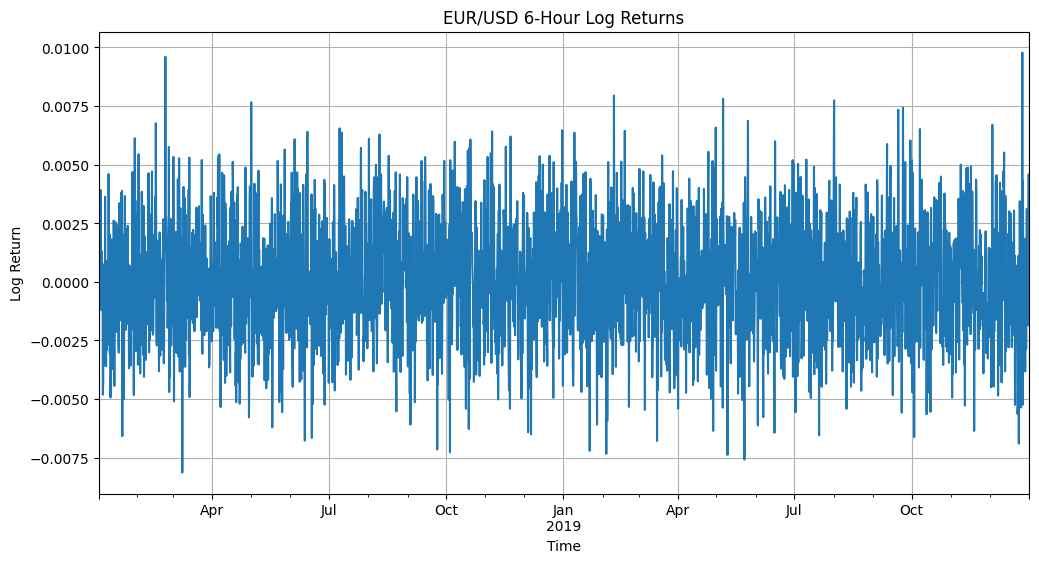

In [17]:
data["returns"].plot(figsize=(12, 6))
plt.title("EUR/USD 6-Hour Log Returns")
plt.xlabel("Time")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()


Returns fluctuate around zero. The contrarian strategy in the next notebook will use these returns to decide whether to go long or short.


## Save the Prepared Data for the Next Notebook

To make the next notebook easier, save the prepared data to a new CSV file.


In [18]:
prepared_path = Path("intraday_prepared.csv")
data.to_csv(prepared_path)

prepared_path


PosixPath('intraday_prepared.csv')

The next notebook can load this prepared dataset directly.


## Final Summary

In this notebook, we prepared the intraday data needed for a simple contrarian strategy.

We:

- loaded or generated 6-hour EUR/USD price data
- standardised the price column name
- inspected the dataset
- checked missing values
- checked the approximate time frequency
- plotted the full price series
- zoomed into one month
- calculated log returns
- dropped the first missing return row
- saved the prepared dataset for the next notebook

The next notebook will use the `returns` column to create and test a simple contrarian strategy.
